# Real-Time AI Risk & Threat Intelligence Platform ( KAMAL HUSSAIN)

This project impemebts an End to End AI/ML Risk & threat intelligence pipieline for detacting potentially risk event in real time.

The system performs data preprocessing,exploratory data analysis,feature Engineering, supervised risk classification unsuervised anomaly detection,risk scoring and model evolution.

It also includes model explainability,pridiction APIs using Fast and a deployment-ready project structure.

For this prototype,synthectic event data is used to simulate real-wold financial and cybersecurity risk signal. the architecure is designed to be extended with real-time steaming & cloud deployment ,monitoring & production data source.

In [ ]:
!pip -q install numpy pandas scikit-learn matplotlib seaborn joblib fastapi uvicorn pydantic requests

In [ ]:
import os, json, time, subprocess, sys, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT = Path("/content/real_time_ai_risk_threat_platform")
ARTIFACTS = PROJECT / "artifacts"
DATA = PROJECT / "data"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
DATA.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT)
print("Project directory:", PROJECT)

Project directory: /content/real_time_ai_risk_threat_platform


In [ ]:
platform_df = pd.read_csv(DATA / 'events.csv')
display(platform_df.head())

,event_id,amount,hour,new_device,location_change,velocity_1h,failed_logins,bytes_sent,connections,unusual_port,protocol,is_risky
0,1,201.28,8,1,0,1,0,1283.12,11,0,2,0
1,2,52.46,8,1,0,0,0,960.57,8,0,2,0
2,3,314.33,0,0,0,4,0,5547.13,6,0,1,0
3,4,380.15,22,0,0,2,1,2149.23,14,0,3,0
4,5,21.09,20,0,0,3,0,369.03,12,0,3,0


In [ ]:
try:
    user_selected_platform_df = pd.read_csv('/real_time_ai_risk_threat_platform.csv')
    print("Successfully loaded /real_time_ai_risk_threat_platform.csv")

    # Preprocess user_selected_platform_df to match schema and add derived features

    # Rename the column that is likely 'is_risky' to 'is_risky'
    # Based on kernel state and 'df' structure, the 12th column (index 11) is assumed to be 'is_risky'.
    # We check if it's named '1' (string) or is implicitly unnamed.
    if len(user_selected_platform_df.columns) == 12: # Ensure it has 12 columns like `df`
        if user_selected_platform_df.columns[11] == '1': # If the 12th column is named '1'
            user_selected_platform_df.rename(columns={'1': 'is_risky'}, inplace=True)
            print("Renamed column '1' to 'is_risky' in user_selected_platform_df.")
        elif 'is_risky' not in user_selected_platform_df.columns: # If 'is_risky' is not explicitly named
            # Assume the last column is 'is_risky' and rename it, handling 'Unnamed: X' or similar.
            user_selected_platform_df.columns = list(user_selected_platform_df.columns[:11]) + ['is_risky']
            print("Renamed the 12th column to 'is_risky' in user_selected_platform_df.")

    # Convert 'protocol' column from categorical strings to numerical using factorize
    # The 'protocol' column is at index 10
    if user_selected_platform_df['protocol'].dtype == 'object':
        user_selected_platform_df['protocol'], _ = pd.factorize(user_selected_platform_df['protocol'])
        print("Converted 'protocol' column to numerical in user_selected_platform_df.")

    # Build features for user_selected_platform_df
    user_selected_X = build_features(user_selected_platform_df)

    # Calculate anomaly_risk for user_selected_platform_df using the pre-trained 'iso' model
    # lo and hi are global variables from cell 131e1eee, calculated from the training data (df's all_anomaly)
    all_anomaly_user = -iso.score_samples(user_selected_X)
    user_selected_platform_df['anomaly_risk'] = np.clip((all_anomaly_user - lo) / (hi - lo + 1e-9), 0, 1)

    display(user_selected_platform_df.head())
except FileNotFoundError:
    print("Error: The file '/real_time_ai_risk_threat_platform.csv' was not found.")
    print("Please ensure the file is uploaded to the root of your Colab environment or specify the correct path.")


Successfully loaded /real_time_ai_risk_threat_platform.csv
Converted 'protocol' column to numerical in user_selected_platform_df.


,event_id,amount,hour,new_device,location_change,velocity_1h,failed_logins,bytes_sent,connections,unusual_port,protocol,is_risky,anomaly_risk
0,1,27.24,8,1,0,7.88,2,210467.69,5,0,0,1,1.000000
1,2,7.10,8,1,0,7.18,2,12423.01,7,0,1,1,1.000000
2,3,42.54,0,0,0,1.55,0,59088.70,6,0,2,0,1.000000
3,4,51.45,22,0,0,2.92,1,8506.34,8,0,0,0,0.220155
4,5,2.85,20,0,0,2.34,0,595681.83,11,0,1,0,1.000000


In [ ]:
print("Missing values in user_selected_platform_df:")
display(user_selected_platform_df.isnull().sum().to_frame("missing_count"))

Missing values in user_selected_platform_df:


,missing_count
event_id,0
amount,0
hour,0
new_device,0
location_change,0
velocity_1h,0
failed_logins,0
bytes_sent,0
connections,0
unusual_port,0


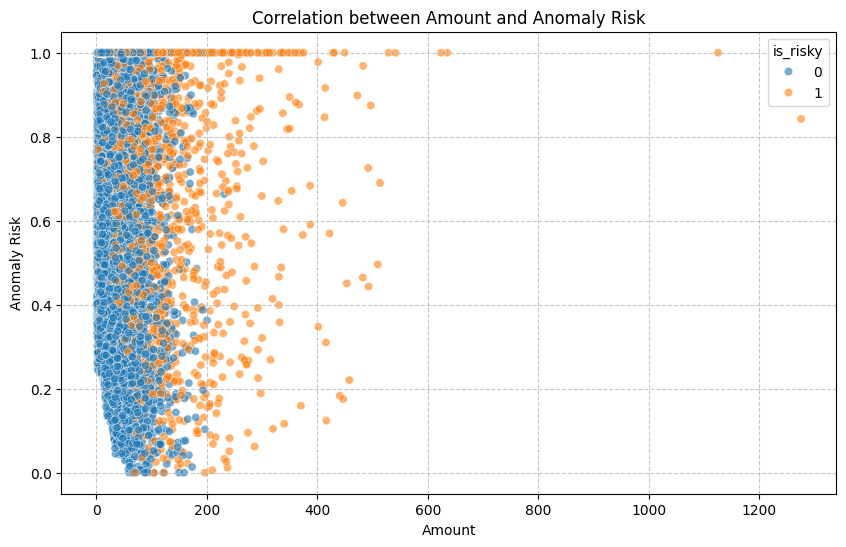

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=user_selected_platform_df, x='amount', y='anomaly_risk', hue='is_risky', alpha=0.6)
plt.title('Correlation between Amount and Anomaly Risk')
plt.xlabel('Amount')
plt.ylabel('Anomaly Risk')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
display(correlation_matrix)

,event_id,amount,hour,new_device,location_change,velocity_1h,failed_logins,bytes_sent,connections,unusual_port,protocol,is_risky,risk_probability,anomaly_risk,risk_score
event_id,1.000000,0.016345,-0.002548,-0.000146,0.001011,-0.004369,-0.009206,-0.011413,-0.007842,-0.003501,-0.012044,0.013324,-0.009305,-0.005650,-0.008531
amount,0.016345,1.000000,0.012213,0.001694,0.002008,0.000335,0.001532,-0.012724,0.001164,-0.001301,-0.009956,-0.008261,-0.002698,0.268533,0.139891
hour,-0.002548,0.012213,1.000000,-0.004848,0.002889,0.000063,-0.004825,-0.004431,0.006839,-0.011039,0.010891,-0.041520,-0.130577,-0.107232,-0.134311
new_device,-0.000146,0.001694,-0.004848,1.000000,0.008656,-0.015148,-0.001761,0.010615,-0.002334,0.004316,0.001336,0.155008,0.448095,0.411174,0.483641
location_change,0.001011,0.002008,0.002889,0.008656,1.000000,0.005304,0.014755,0.002509,-0.008801,0.015175,-0.003266,0.114756,0.382861,0.420063,0.449451
velocity_1h,-0.004369,0.000335,0.000063,-0.015148,0.005304,1.000000,0.015344,-0.001662,-0.010856,0.014051,-0.009562,0.094682,0.284427,0.070121,0.206427
failed_logins,-0.009206,0.001532,-0.004825,-0.001761,0.014755,0.015344,1.000000,-0.014090,0.010160,0.005896,0.000066,0.143709,0.436740,0.210903,0.371382
bytes_sent,-0.011413,-0.012724,-0.004431,0.010615,0.002509,-0.001662,-0.014090,1.000000,0.001826,0.010234,-0.003272,0.009765,0.032874,0.312062,0.183979
connections,-0.007842,0.001164,0.006839,-0.002334,-0.008801,-0.010856,0.010160,0.001826,1.000000,0.005213,0.012511,0.068772,0.188277,-0.024267,0.099422
unusual_port,-0.003501,-0.001301,-0.011039,0.004316,0.015175,0.014051,0.005896,0.010234,0.005213,1.000000,0.000496,0.082722,0.247870,0.369989,0.342616


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=correlation_matrix)

https://docs.google.com/spreadsheets/d/1THqy5D6KA08fHUCQkpqhGNcNaNHdXIS2Nnxyf_Xq32U/edit#gid=0


This table shows the correlation matrix for all numeric columns in the `df` DataFrame. Each cell `(i, j)` in the matrix represents the Pearson correlation coefficient between column `i` and column `j`.

*   **Values close to 1:** Indicate a strong positive linear relationship.
*   **Values close to -1:** Indicate a strong negative linear relationship.
*   **Values close to 0:** Indicate a weak or no linear relationship.

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
display(numeric_df.describe())

,event_id,amount,hour,new_device,location_change,velocity_1h,failed_logins,bytes_sent,connections,unusual_port,protocol,is_risky,risk_probability,anomaly_risk,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,247.000840,11.515800,0.119950,0.100900,2.994850,0.505700,5498.140552,7.997050,0.056900,1.499500,0.127550,0.127858,0.356555,18.503490
std,5773.647028,321.403749,6.901647,0.324911,0.301204,1.733688,0.714418,9505.619385,2.830149,0.231657,1.117704,0.333596,0.097238,0.257886,12.237811
min,1.000000,1.840000,0.000000,0.000000,0.000000,0.000000,0.000000,44.640000,0.000000,0.000000,0.000000,0.000000,0.012200,0.000000,2.700000
25%,5000.750000,75.937500,6.000000,0.000000,0.000000,2.000000,0.000000,1417.595000,6.000000,0.000000,0.000000,0.000000,0.064166,0.146464,9.300000
50%,10000.500000,148.155000,11.000000,0.000000,0.000000,3.000000,0.000000,3020.890000,8.000000,0.000000,2.000000,0.000000,0.094594,0.301315,15.100000
75%,15000.250000,290.840000,17.000000,0.000000,0.000000,4.000000,1.000000,6306.567500,10.000000,0.000000,2.000000,0.000000,0.156575,0.527371,24.700000
max,20000.000000,9426.130000,23.000000,1.000000,1.000000,12.000000,5.000000,724041.310000,22.000000,1.000000,3.000000,1.000000,0.844024,1.000000,88.300000


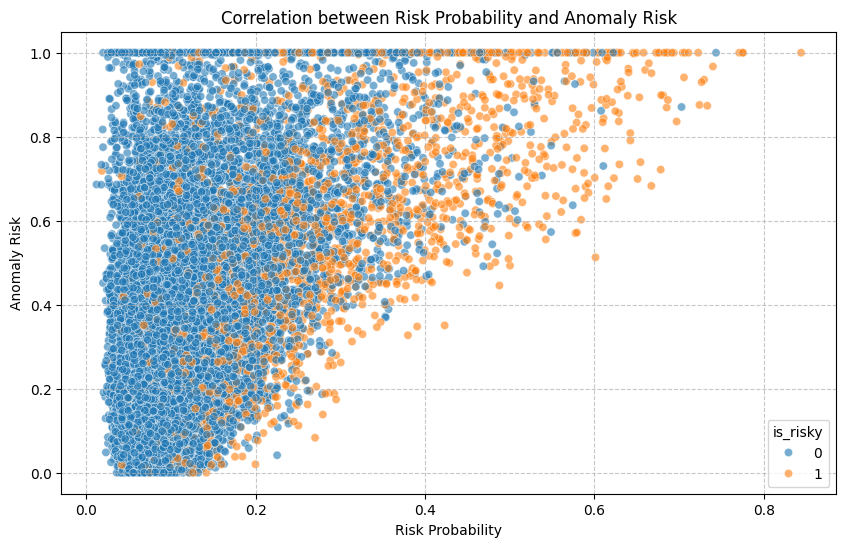

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='risk_probability', y='anomaly_risk', hue='is_risky', alpha=0.6)
plt.title('Correlation between Risk Probability and Anomaly Risk')
plt.xlabel('Risk Probability')
plt.ylabel('Anomaly Risk')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

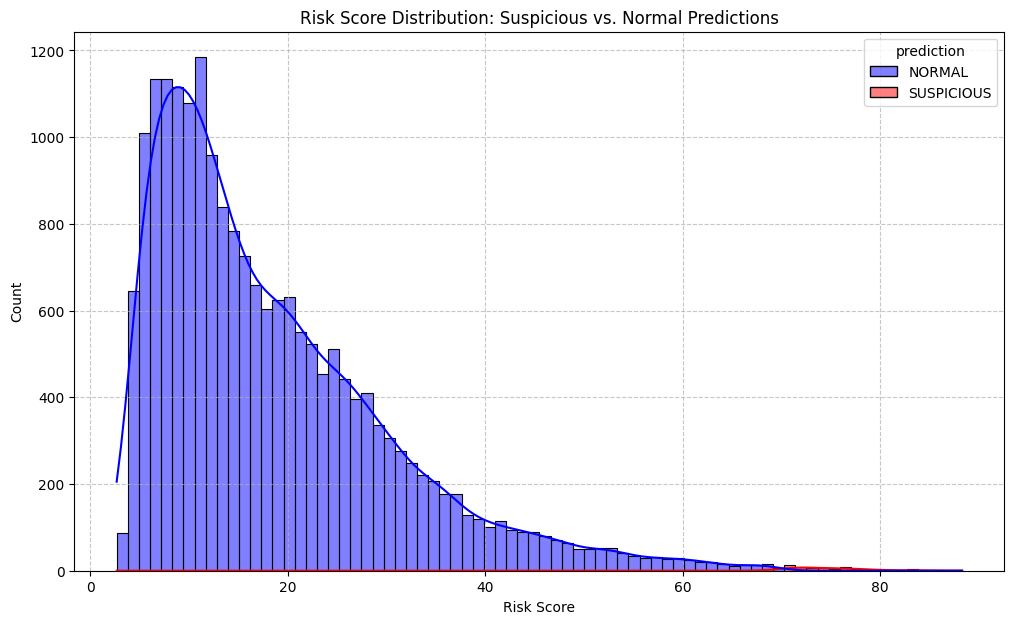

In [ ]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='risk_score', hue='prediction', kde=True, palette={'SUSPICIOUS': 'red', 'NORMAL': 'blue'})
plt.title('Risk Score Distribution: Suspicious vs. Normal Predictions')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Generate realistic demo events

In [ ]:
def generate_events(n=20000, seed=42):
    rng = np.random.default_rng(seed)
    amount = np.exp(rng.normal(5.0, 1.0, n)).round(2)
    hour = rng.integers(0, 24, n)
    new_device = rng.binomial(1, 0.12, n)
    location_change = rng.binomial(1, 0.10, n)
    velocity_1h = rng.poisson(3, n)
    failed_logins = rng.poisson(0.5, n)
    bytes_sent = np.exp(rng.normal(8.0, 1.1, n))
    connections = rng.poisson(8, n)
    unusual_port = rng.binomial(1, 0.06, n)
    protocol = rng.integers(0, 4, n)

    logit = (-4.0 + 0.000008*amount + 1.2*new_device +
             1.0*location_change + 0.18*velocity_1h +
             0.55*failed_logins + 0.8*unusual_port +
             0.08*connections + 0.35*(hour <= 4) +
             0.25*(bytes_sent > np.quantile(bytes_sent, 0.90)))
    prob = 1/(1+np.exp(-logit))
    is_risky = (rng.random(n) < prob).astype(int)

    return pd.DataFrame({
        "event_id": np.arange(1, n+1),
        "amount": amount, "hour": hour, "new_device": new_device,
        "location_change": location_change, "velocity_1h": velocity_1h,
        "failed_logins": failed_logins, "bytes_sent": bytes_sent.round(2),
        "connections": connections, "unusual_port": unusual_port,
        "protocol": protocol, "is_risky": is_risky
    })

df = generate_events()
df.to_csv(DATA/"events.csv", index=False)
print("Shape:", df.shape)
display(df.head())

Shape: (20000, 12)


,event_id,amount,hour,new_device,location_change,velocity_1h,failed_logins,bytes_sent,connections,unusual_port,protocol,is_risky
0,1,201.28,8,1,0,1,0,1283.12,11,0,2,0
1,2,52.46,8,1,0,0,0,960.57,8,0,2,0
2,3,314.33,0,0,0,4,0,5547.13,6,0,1,0
3,4,380.15,22,0,0,2,1,2149.23,14,0,3,0
4,5,21.09,20,0,0,3,0,369.03,12,0,3,0


## 2. Data quality + EDA

Missing values:


,missing
event_id,0
amount,0
hour,0
new_device,0
location_change,0
velocity_1h,0
failed_logins,0
bytes_sent,0
connections,0
unusual_port,0



Class distribution:


,count
is_risky,
normal,17449
risky,2551


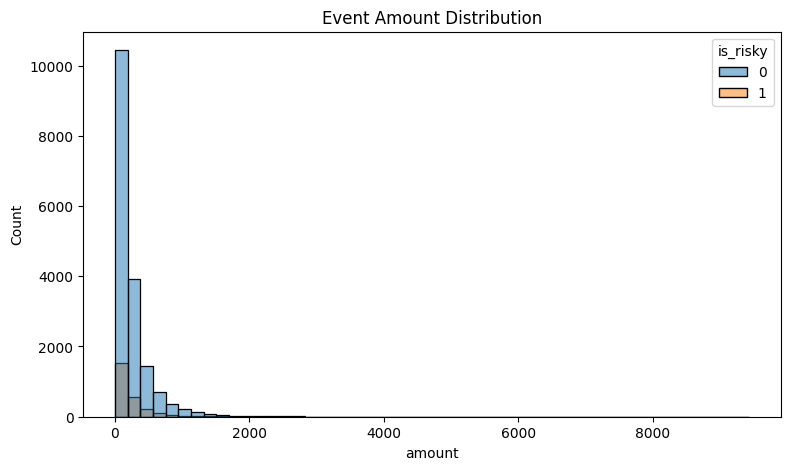

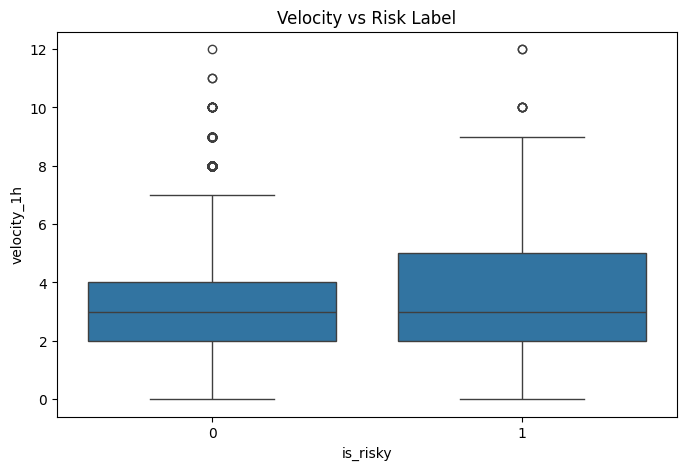

In [ ]:
print("Missing values:")
display(df.isna().sum().to_frame("missing"))

print("\nClass distribution:")
display(df["is_risky"].value_counts().rename(index={0:"normal",1:"risky"}).to_frame("count"))

plt.figure(figsize=(9,5))
sns.histplot(data=df, x="amount", hue="is_risky", bins=50)
plt.title("Event Amount Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="is_risky", y="velocity_1h")
plt.title("Velocity vs Risk Label")
plt.show()

## 3. Feature engineering

In [ ]:
FEATURES = [
    "amount","hour","new_device","location_change","velocity_1h",
    "failed_logins","bytes_sent","connections","unusual_port","protocol"
]

def build_features(frame):
    x = frame[FEATURES].copy()
    x["log_amount"] = np.log1p(x["amount"])
    x["is_night"] = ((x["hour"] <= 5) | (x["hour"] >= 23)).astype(int)
    x["traffic_intensity"] = x["bytes_sent"]/(x["connections"]+1)
    return x

X = build_features(df)
y = df["is_risky"]
print("Feature matrix:", X.shape)
display(X.head())

Feature matrix: (20000, 13)


,amount,hour,new_device,location_change,velocity_1h,failed_logins,bytes_sent,connections,unusual_port,protocol,log_amount,is_night,traffic_intensity
0,201.28,8,1,0,1,0,1283.12,11,0,2,5.309653,0,106.926667
1,52.46,8,1,0,0,0,960.57,8,0,2,3.978934,0,106.730000
2,314.33,0,0,0,4,0,5547.13,6,0,1,5.753620,1,792.447143
3,380.15,22,0,0,2,1,2149.23,14,0,3,5.943193,0,143.282000
4,21.09,20,0,0,3,0,369.03,12,0,3,3.095125,0,28.386923


## 4. Train supervised ML + anomaly detection

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_score, recall_score, f1_score
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

clf = HistGradientBoostingClassifier(
    max_iter=250, learning_rate=0.08, max_leaf_nodes=31, random_state=42
)
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:,1]
pred = (proba >= 0.50).astype(int)

iso = IsolationForest(n_estimators=250, contamination=0.05, random_state=42)
iso.fit(X_train)

metrics = {
    "roc_auc": roc_auc_score(y_test, proba),
    "average_precision": average_precision_score(y_test, proba),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1": f1_score(y_test, pred)
}
print(json.dumps({k: round(float(v),4) for k,v in metrics.items()}, indent=2))
print("\nClassification report:")
print(classification_report(y_test, pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, pred))

{
  "roc_auc": 0.699,
  "average_precision": 0.285,
  "precision": 0.5882,
  "recall": 0.0392,
  "f1": 0.0735
}

Classification report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      3490
           1       0.59      0.04      0.07       510

    accuracy                           0.87      4000
   macro avg       0.73      0.52      0.50      4000
weighted avg       0.84      0.87      0.82      4000

Confusion matrix:
[[3476   14]
 [ 490   20]]


## 5. Risk scoring engine

In [ ]:
def risk_level(score):
    if score >= 90: return "CRITICAL"
    if score >= 70: return "HIGH"
    if score >= 30: return "MEDIUM"
    return "LOW"

# Convert anomaly signal into a stable 0-1 range for this demo batch.
all_anomaly = -iso.score_samples(X)
lo, hi = np.percentile(all_anomaly, [2, 98])
anomaly_risk = np.clip((all_anomaly-lo)/(hi-lo+1e-9), 0, 1)

full_probability = clf.predict_proba(X)[:,1]
df["risk_probability"] = full_probability
df["anomaly_risk"] = anomaly_risk
df["risk_score"] = np.round(100*(0.75*full_probability + 0.25*anomaly_risk), 1)
df["risk_level"] = df["risk_score"].apply(risk_level)
df["prediction"] = np.where(df["risk_score"] >= 70, "SUSPICIOUS", "NORMAL")

df.to_csv(DATA/"scored_events.csv", index=False)
display(df.sort_values("risk_score", ascending=False).head(15))

,event_id,amount,hour,new_device,location_change,velocity_1h,failed_logins,bytes_sent,connections,unusual_port,protocol,is_risky,risk_probability,anomaly_risk,risk_score,risk_level,prediction
8865,8866,144.83,20,1,1,5,0,13905.56,14,1,2,1,0.844024,1.000000,88.3,HIGH,SUSPICIOUS
8728,8729,204.07,3,1,1,5,1,4852.54,15,0,1,1,0.775322,1.000000,83.1,HIGH,SUSPICIOUS
3094,3095,921.69,15,1,1,4,3,251.32,6,1,2,1,0.775181,1.000000,83.1,HIGH,SUSPICIOUS
3816,3817,139.38,3,1,0,6,0,6709.94,17,1,2,1,0.771033,1.000000,82.8,HIGH,SUSPICIOUS
17692,17693,78.59,1,1,0,8,1,16239.85,8,0,3,0,0.743646,1.000000,80.8,HIGH,SUSPICIOUS
1188,1189,273.96,22,1,1,3,2,5645.52,12,0,0,1,0.740022,0.967289,79.7,HIGH,SUSPICIOUS
16901,16902,138.63,1,1,0,5,1,315.48,12,1,3,1,0.722602,1.000000,79.2,HIGH,SUSPICIOUS
12147,12148,15.35,5,1,1,6,0,556.38,5,0,3,1,0.711120,1.000000,78.3,HIGH,SUSPICIOUS
1514,1515,27.60,4,1,0,8,1,5424.35,6,0,2,1,0.729558,0.935750,78.1,HIGH,SUSPICIOUS
10952,10953,480.20,0,1,1,2,2,26988.33,10,0,2,1,0.706798,1.000000,78.0,HIGH,SUSPICIOUS


## 6. Explainability — top factors for a flagged event

In [ ]:
# Model-agnostic local contribution demo.
# Each feature is perturbed toward its training median; change in probability
# estimates how much that feature contributes to the current decision.

def explain_row(row, model):
    base = pd.DataFrame([row])
    base_X = build_features(base)
    base_p = float(model.predict_proba(base_X)[:,1][0])
    med = X_train.median()
    contributions = {}
    for col in FEATURES:
        altered = base_X.copy()
        altered[col] = med[col]
        new_p = float(model.predict_proba(altered)[:,1][0])
        contributions[col] = base_p - new_p
    return base_p, pd.Series(contributions).sort_values(key=np.abs, ascending=False)

sample = df.sort_values("risk_score", ascending=False).iloc[0]
base_p, contributions = explain_row(sample, clf)

print("Event:", int(sample.event_id))
print("Risk score:", sample.risk_score, "| Level:", sample.risk_level)
print("Model probability:", round(base_p,4))
display(contributions.head(8).to_frame("local_contribution"))

Event: 8866
Risk score: 88.3 | Level: HIGH
Model probability: 0.844


,local_contribution
connections,0.271349
new_device,0.255164
velocity_1h,0.172731
unusual_port,0.101768
location_change,0.097094
protocol,0.048685
hour,0.039015
bytes_sent,0.017747


## 7. Save model artifacts

In [ ]:
joblib.dump(clf, ARTIFACTS/"risk_classifier.joblib")
joblib.dump(iso, ARTIFACTS/"anomaly_detector.joblib")
(ARTIFACTS/"metrics.json").write_text(json.dumps(
    {k: float(v) for k,v in metrics.items()}, indent=2
))
print("Saved:")
for p in ARTIFACTS.iterdir():
    print(" -", p.name)

Saved:
 - risk_classifier.joblib
 - anomaly_detector.joblib
 - EVENT R AI RISK & THREAD.csv
 - metrics.json


In [ ]:
df.to_csv(DATA / "processed_df.csv", index=False)
print("Saved processed DataFrame to:", DATA / "processed_df.csv")

Saved processed DataFrame to: /content/real_time_ai_risk_threat_platform/data/processed_df.csv


## 8. Test a single event through the same risk pipeline

In [ ]:
event = {
    "amount": 185000.0,
    "hour": 3,
    "new_device": 1,
    "location_change": 1,
    "velocity_1h": 12,
    "failed_logins": 4,
    "bytes_sent": 50000.0,
    "connections": 25,
    "unusual_port": 1,
    "protocol": 2
}

one = pd.DataFrame([event])
one_X = build_features(one)
p = float(clf.predict_proba(one_X)[:,1][0])
raw_a = float(-iso.score_samples(one_X)[0])
a = float(np.clip((raw_a-lo)/(hi-lo+1e-9),0,1))
score = round(100*(0.75*p+0.25*a),1)

result = {
    "risk_score": score,
    "risk_level": risk_level(score),
    "risk_probability": round(p,4),
    "anomaly_signal": round(a,4),
    "prediction": "SUSPICIOUS" if score >= 70 else "NORMAL"
}
print(json.dumps(result, indent=2))

{
  "risk_score": 81.1,
  "risk_level": "HIGH",
  "risk_probability": 0.7479,
  "anomaly_signal": 1.0,
  "prediction": "SUSPICIOUS"
}


## 9. Create the FastAPI application file

In [ ]:
api_code = r'''
from pathlib import Path
import joblib
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel

ROOT = Path("/content/real_time_ai_risk_threat_platform")
clf = joblib.load(ROOT/"artifacts/risk_classifier.joblib")
iso = joblib.load(ROOT/"artifacts/anomaly_detector.joblib")

FEATURES = ["amount","hour","new_device","location_change","velocity_1h",
            "failed_logins","bytes_sent","connections","unusual_port","protocol"]

def build_features(df):
    import numpy as np
    x = df[FEATURES].copy()
    x["log_amount"] = np.log1p(x["amount"])
    x["is_night"] = ((x["hour"] <= 5) | (x["hour"] >= 23)).astype(int)
    x["traffic_intensity"] = x["bytes_sent"]/(x["connections"]+1)
    return x

def level(s):
    if s >= 90: return "CRITICAL"
    if s >= 70: return "HIGH"
    if s >= 30: return "MEDIUM"
    return "LOW"

app = FastAPI(title="AI Risk & Threat Intelligence API")

class Event(BaseModel):
    amount: float
    hour: int
    new_device: int
    location_change: int
    velocity_1h: int
    failed_logins: int
    bytes_sent: float
    connections: int
    unusual_port: int
    protocol: int

@app.get("/health")
def health():
    return {"status":"ok"}

@app.post("/predict")
def predict(event: Event):
    df = pd.DataFrame([event.model_dump()])
    X = build_features(df)
    p = float(clf.predict_proba(X)[:,1][0])
    a = float(min(max((-iso.score_samples(X)[0]-0.3)/0.7,0),1))
    score = round(100*(0.75*p+0.25*a),1)
    return {
        "risk_score": score,
        "risk_level": level(score),
        "risk_probability": round(p,4),
        "anomaly_signal": round(a,4),
        "prediction": "SUSPICIOUS" if score >= 70 else "NORMAL"
    }
'''
(PROJECT/"api_app.py").write_text(api_code)
print("Created", PROJECT/"api_app.py")

Created /content/real_time_ai_risk_threat_platform/api_app.py


## 10. Run and test the API in Colab

In [ ]:
proc = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "api_app:app", "--host", "127.0.0.1", "--port", "8000"],
    cwd=str(PROJECT), stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(2)

import requests
print("Health:", requests.get("http://127.0.0.1:8000/health").json())
print("Prediction:", requests.post(
    "http://127.0.0.1:8000/predict", json=event
).json())

Health: {'status': 'ok'}
Prediction: {'risk_score': 72.7, 'risk_level': 'HIGH', 'risk_probability': 0.7479, 'anomaly_signal': 0.6645, 'prediction': 'SUSPICIOUS'}


In [ ]:
dockerfile_content = r'''
# Use an official Python runtime as a parent image
FROM python:3.9-slim-buster

# Set the working directory in the container
WORKDIR /app

# Copy the current directory contents into the container at /app
COPY ./api_app.py /app/api_app.py
COPY ./artifacts /app/artifacts
COPY ./data /app/data

# Install any needed packages specified in requirements.txt
# For this project, we manually list them as they were installed ad-hoc
RUN pip install --no-cache-dir numpy pandas scikit-learn fastapi uvicorn pydantic

# Make port 8000 available to the world outside this container
EXPOSE 8000

# Run the FastAPI application using Uvicorn
CMD ["uvicorn", "api_app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

(PROJECT / "Dockerfile").write_text(dockerfile_content)
print("Created Dockerfile in:", PROJECT / "Dockerfile")

Created Dockerfile in: /content/real_time_ai_risk_threat_platform/Dockerfile


** POTFOLIO CHEKLIST **

1.Data preprocessing & EDA

2.Feature Engineering

3.Risk Classification Model

4.Anomaly Detection

5.Risk Scoring

6.Model Evalution

7.Explanable AI

8.Fast API Prediction API

9.Model Export & Interence Pipline

10.Deploment-Ready Architecture

Tech stack, Python | Pandas| Numpy | Scikit-learn|
|Fast API |SQL|Git